In [2]:
import os, sys
from pprint import pprint
import matplotlib.pyplot as plt
import matplotlib.patches as patches






sys.path.append(os.path.dirname(os.getcwd()))
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
from constants import PYGARMENT_ROOT, DATASET_ROOT, PROJECT_ROOT

module_path = os.path.abspath(os.path.dirname(os.getcwd()))
if module_path not in sys.path:
    sys.path.append(module_path)



sys.path.append(PYGARMENT_ROOT)
import pygarment as pyg


## Data Structure for Panel, Stitich and Sewing Pattern

In [242]:
import os 
import sys

sys.path.append(os.path.dirname(os.getcwd()))
from constants import PYGARMENT_ROOT
sys.path.append(PYGARMENT_ROOT)
import pygarment as pyg

import pickle
import numpy as np
import svgpathtools as svgpath
from PIL import Image
from copy import deepcopy
from torch.utils.data import Dataset
import random


from dataclasses import dataclass, field
from typing import List, Dict, Tuple
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


@dataclass
class Stitch :
    panel_0 : str
    edge_0 : int
    panel_1 : str
    edge_1 : int
    stitch_direction : bool
    

class StitchDict:
    def __init__(self, raw_stitch_dict: Dict[int, List[Dict]]):
        """
        Initialize the StitchManager from a raw stitch dictionary.        
        raw_stitch_dict: keys are stitch ids and values are lists of two dictionaries
        with 'panel' and 'edge' keys.
        """
        self._stitches: Dict[int, Stitch] = {}
        for stitch_id, stitch_pair in raw_stitch_dict.items():
            # Each stitch_pair contains two entries representing the two sides of the stitch.
            side0 = stitch_pair[0]
            side1 = stitch_pair[1]
            # Optionally, you could compute stitch_direction from panel names or edges.
            stitch_direction = False  # You can update this logic as needed.
            self._stitches[stitch_id] = Stitch(
                panel_0=side0['panel'],
                edge_0=side0['edge'],
                panel_1=side1['panel'],
                edge_1=side1['edge'],
                stitch_direction=stitch_direction
            )
    
    def reindex(
        self,
        mapping: Dict[int, int],
    ) -> None:
        """
        Re-index the internal dictionary using a provided mapping.
        For example, mapping could be ann_to_img_seam_idx_map or img_to_ann_seam_idx_map.
        """
        new_stitches = {}
        for old_key, stitch in self._stitches.items():
            new_key = mapping.get(old_key, old_key)
            new_stitches[new_key] = stitch
        self._stitches = new_stitches
    
    def __getitem__(self, key: int) -> Stitch:
        return self._stitches[key]
    
    def __setitem__(self, key: int, value: Stitch) -> None:
        self._stitches[key] = value
    
    def items(self):
        return self._stitches.items()

    def __len__(self):
        return len(self._stitches)
    
    def __repr__(self):
        return repr(self._stitches)



In [250]:


class SVGPanel:
    def __init__(self, svg_path: List[svgpath.Path]):
        self.svg_path = svg_path

    def translate(self, dx: float, dy: float) -> None:
        """
        Translate the panel by dx along x-axis and dy along y-axis.
        """
        # In the complex plane, translation by (dx, dy) means adding (dx + dy*j)
        delta = dx + dy * 1j
        self.svg_path = svgpath.Path(*[path.translated(delta) for path in self.svg_path])


    def scale(self, factor: float, pivot: np.ndarray = np.array([0, 0])) -> None:
        """
        Scale the panel by the given factor relative to the pivot.
        By default, the pivot is 0 (the origin), but you can specify a different pivot point.
        """
        pivot_complex = pivot[0] + pivot[1] * 1j
        self.svg_path = svgpath.Path(*[
            (path.translated(-pivot_complex)).scaled(factor).translated(pivot_complex) for path in self.svg_path
        ])
        
    def rotate_clockwise(self, angle_degrees: float, pivot: np.ndarray = np.array([0, 0])) -> None:
        """
        Rotate the entire path by a given angle in degrees around a pivot point.
        
        Args:
            angle_degrees: The angle to rotate the path, in degrees.
            pivot: The point around which to rotate the path. Default is the origin (0+0j).
        """
        pivot_complex = pivot[0] + pivot[1] * 1j
        self.svg_path = svgpath.Path(*[
            path.rotated(angle_degrees, pivot_complex) for path in self.svg_path
        ])
        
    def mirror_horizontal(self) -> None:
        """
        Mirror the panel horizontally (flip the x-axis).
        """
        # self.svg_path = [svgpath.Path(*[self._mirror_horizontal_segment(seg) for seg in path]) for path in self.svg_path]
        self.svg_path = svgpath.Path(*[self._mirror_horizontal_segment(seg) for seg in self.svg_path])        

    def mirror_vertical(self) -> None:
        """
        Mirror the panel vertically (flip the y-axis).
        """
        # self.svg_path = [svgpath.Path(*[self._mirror_vertical_segment(seg) for seg in path]) for path in self.svg_path]
        self.svg_path = svgpath.Path(*[self._mirror_vertical_segment(seg) for seg in self.svg_path])

    def _mirror_horizontal_segment(self, segment):
        if isinstance(segment, svgpath.Arc):
            # Mirror the start and end points horizontally
            start = complex(-segment.start.real, segment.start.imag)
            end = complex(-segment.end.real, segment.end.imag)
            # Reverse the sweep flag
            sweep = not segment.sweep
            return svgpath.Arc(start=start, radius=segment.radius, rotation=segment.rotation,
                       large_arc=segment.large_arc, sweep=sweep, end=end)
        else:
            return segment.scaled(-1, 1)

    def _mirror_vertical_segment(self, segment):
        if isinstance(segment, svgpath.Arc):
            # Mirror the start and end points vertically
            start = complex(segment.start.real, -segment.start.imag)
            end = complex(segment.end.real, -segment.end.imag)
            # Reverse the sweep flag
            sweep = not segment.sweep
            return svgpath.Arc(start=start, radius=segment.radius, rotation=segment.rotation,
                       large_arc=segment.large_arc, sweep=sweep, end=end)
        else:
            return segment.scaled(1, -1)

    def draw(
        self,
        ax          : plt.Axes = None,
        panel_name  : str = None,
        N_SAMPLE_PER_EDGE : int = 80,
        stitch_list : List[int] = None,
        edge_color_list : List[Tuple[float, float, float]] = None
    ) -> None:
        if stitch_list is not None :
            assert len(stitch_list) == len(self.svg_path), "stitch_list must be the same length as the number of edges"
        if ax is None :
            ax = plt.gca()
        if panel_name is not None :
            ax.set_title(panel_name)
        if edge_color_list is None :
            edge_color_list = plt.cm.rainbow(np.linspace(0, 1, len(self.svg_path)))
         
        path_start_pos = np.array([self.svg_path[0].start.real, self.svg_path[0].start.imag])   
        for dx, dy in [(-1, -1), (-1, 1), (1, -1), (1, 1)]:
            ax.annotate(
                "0",
                path_start_pos + np.array([dx, dy]),
                color = "white", fontweight = "bold",
                fontsize = 9
            )
        ax.annotate(
            "0",
            path_start_pos,
            color = "black", # fontweight = "bold",
            fontsize = 9
        )
        for edge_idx, (edge, edge_color) in enumerate(zip(self.svg_path, edge_color_list)) :
            ax.add_patch(
                FancyArrowPatch(
                    [edge.start.real, edge.start.imag],
                    [edge.end.real, edge.end.imag],
                    arrowstyle='-|>',
                    mutation_scale=15,
                    color = "black",
                    linewidth = 0.5
                )
            )
            ax.scatter(
                list(map(lambda t : edge.point(t).real, np.linspace(0, 1, N_SAMPLE_PER_EDGE))),
                list(map(lambda t : edge.point(t).imag, np.linspace(0, 1, N_SAMPLE_PER_EDGE))),
                s = 0.5, color = edge_color
            )
            if stitch_list is not None :
                # for dx, dy in [(-1, -1), (-1, 1), (1, -1), (1, 1)]:
                #     ax.annotate(
                #         f"{stitch_list[edge_idx]}",
                #         [
                #             (edge.start.real + edge.end.real) / 2 + dx,
                #             (edge.start.imag + edge.end.imag) / 2 + dy
                #         ],
                #         color = "white", # fontweight = "bold",
                #         fontsize = 11, fontweight = "bold"
                #     )
                ax.annotate(
                    f"{stitch_list[edge_idx]}",
                    [
                        (edge.start.real + edge.end.real) / 2,
                        (edge.start.imag + edge.end.imag) / 2
                    ],
                    color = edge_color,
                    fontsize = 11, fontweight = "bold"
                )
        ax.invert_yaxis()
        ax.axis("equal")
        
    def is_clockwise(self) -> bool:
        """
        Determine if the path is clockwise.
        """
        total = 0
        for segment in self.svg_path:
            start = segment.start
            end = segment.end
            total += (end.real - start.real) * (end.imag + start.imag)
        return total <= 0

    def reverse_path(self) -> None:
        """
        Reverse the order of the path segments and their directions.
        """
        reversed_segments = []
        for segment in reversed(self.svg_path):
            reversed_segment = segment.reversed()
            reversed_segments.append(reversed_segment)
        self.svg_path = svgpath.Path(*reversed_segments)
        
    def set_start(self, idx: int) -> None :
        """
        Set the start point of the path to the point at index idx.
        """
        self.svg_path = svgpath.Path(*(self.svg_path[idx:] + self.svg_path[:idx]))

    def min_distance_to_point(self, point: complex) -> float:
        """
        Calculate the minimum distance from any point on the panel to a given point.
        
        Args:
            point: A complex number representing the point in the complex plane.
            
        Returns:
            float: The minimum distance from any point on the panel to the given point.
        """
        min_distance = float('inf')
        for path in self.svg_path:
            for segment in path:
                distance = segment.distance(point)
                if distance < min_distance:
                    min_distance = distance
        return min_distance
    
    def bbox(self) :
        """
        (xmin, ymin, xmax, ymax)
        """
        xmin, xmax, ymin, ymax = svgpath.Path(*self.svg_path).bbox()
        return xmin, ymin, xmax, ymax
    
    def get_center(self) :
        xmin, ymin, xmax, ymax = self.bbox()
        return np.array([(xmin + xmax) / 2, (ymin + ymax) / 2])
    
    def __repr__(self):
        return f"Panel(svg_path={self.svg_path})"


In [247]:

class SewingPattern :
    def __init__(self,
        panel_svg_path_dict : Dict[str, List[svgpath.Path]],
        stitch_dict : Dict[int, List[Dict]],
        panel_name_refine_map : Dict[str, str] = None,
    ) :
        self.panel_dict = {
            panel_name : SVGPanel(panel_svg_path[0])
            for panel_name, panel_svg_path in panel_svg_path_dict.items()
        }
        self.stitch_dict = StitchDict(stitch_dict)
        self.panel_name_refine_map = panel_name_refine_map
    
    def apply_panel_name_refine_map(
        self, panel_name_refine_map : Dict[str, str] = None
    ) :
        if panel_name_refine_map is None :
            panel_name_refine_map = self.panel_name_refine_map
        for panel_name in self.panel_name_list :
            self.panel_dict[panel_name_refine_map[panel_name]] = self.panel_dict[panel_name]
            del self.panel_dict[panel_name]
    @property
    def panel_name_list(self) :
        return list(self.panel_dict.keys())
    @property
    def panel_list(self) :
        return list(self.panel_dict.values())
    
    def reverse_panel_path(self, panel_name : str) :
        panel_edge_len = len(self.panel_dict[panel_name].svg_path)
        self.panel_dict[panel_name].reverse_path()
        for stch_id, stitch in self.stitch_dict.items() :
            if stitch.panel_0 == panel_name :
                stitch.edge_0 = panel_edge_len - 1 - stitch.edge_0
            if stitch.panel_1 == panel_name :
                stitch.edge_1 = panel_edge_len - 1 - stitch.edge_1
       
    def draw(
        self,
        # ax : plt.Axes = None,
        FIGLEN : int = 5,
        N_SAMPLE_PER_EDGE : int = 80, 
        show=False
    ) :
        NROWS = int(np.ceil(len(self.panel_dict) ** 0.5))
        NCOLS = int(np.ceil(len(self.panel_dict) / NROWS))
        plt.figure(figsize=(FIGLEN*NCOLS, FIGLEN*NROWS))
        
        color_list = plt.cm.rainbow(np.linspace(0, 1, len(self.stitch_dict)))
        for panel_idx, (panel_name, panel) in enumerate(self.panel_dict.items()) :
            stitch_idx_list = []
            edge_color_list = []
            for edge_idx, edge in enumerate(panel.svg_path) :
                stitch_idx = -1
                for stitch_id, stitch in self.stitch_dict.items() :
                    if (
                        stitch.panel_0 == panel_name and stitch.edge_0 == edge_idx
                    ) or (
                        stitch.panel_1 == panel_name and stitch.edge_1 == edge_idx
                    ):
                        stitch_idx = stitch_id
                        break
                stitch_idx_list.append(stitch_idx)
                edge_color_list.append(color_list[stitch_idx] if stitch_idx != -1 else "black")
            
            # print(len(panel.svg_path), len(edge_color_list), len(stitch_idx_list))
            
            
            ax = plt.subplot(NROWS, NCOLS, panel_idx + 1)
            panel.draw(
                ax, panel_name, N_SAMPLE_PER_EDGE,
                stitch_idx_list, edge_color_list
            )
        if show :
            plt.show()
    
@dataclass
class ParameterizedSeamLine :
    whole_stch_vert_idx_arr : np.ndarray = None
    whole_stch_vert_vis_mask : np.ndarray = None
    # whole_stch_vert_projected_pos_arr : np.ndarray = None
    
    segment_vert_idx_arr_list : List[np.ndarray] = None
    segment_vert_pos_arr_list : List[np.ndarray] = None
    segment_edge_len_arr_list : List[np.ndarray] = None
    segment_t_arr_list : List[np.ndarray] = None
    segment_u_arr_list : List[np.ndarray] = None
    segment_v_arr_list : List[np.ndarray] = None
    
    def translate(self, dx : float, dy : float) :
        for segment_vert_pos_arr in self.segment_vert_pos_arr_list :
            segment_vert_pos_arr[:, 0] += dx
            segment_vert_pos_arr[:, 1] += dy


@dataclass
class ParameterizedEdgeLine :
    pass
    
class SingleViewLabel :
    """
    class for label of single image
    """    
    def __init__(self,
        img,
        img_foreground_mask : np.ndarray,
        vert_visibility_mask : np.ndarray,
        vert_projected_pos_arr : np.ndarray,
        fltrd_vis_seam_line_dict : Dict[int, Dict[str, ParameterizedSeamLine]],
    ) :
        self.img = img.convert("RGB")
        self.img_foreground_mask = img_foreground_mask
        self.vert_visibility_mask = vert_visibility_mask
        self.vert_projected_pos_arr = vert_projected_pos_arr
        
        self.seam_line_dict = {}
        for seam_line_idx, seam_line in fltrd_vis_seam_line_dict.items() :
            self.seam_line_dict[seam_line_idx] = ParameterizedSeamLine(
                whole_stch_vert_idx_arr = seam_line["raw_idx_arr"],
                whole_stch_vert_vis_mask = seam_line["raw_vis_mask"],
                segment_vert_idx_arr_list = seam_line["segment_idx_arr_list"],
                segment_vert_pos_arr_list = seam_line["segment_pos_arr_list"],
                segment_edge_len_arr_list = seam_line["segment_edge_len_arr_list"],
                segment_t_arr_list = seam_line["segment_t_arr_list"],
                segment_u_arr_list = seam_line["segment_u_arr_list"],
                segment_v_arr_list = seam_line["segment_v_arr_list"],
            )

    def crop(self, crop_l : int, crop_t : int, crop_r : int, crop_b : int) :
        """
        crop_l, crop_t, crop_r, crop_b : int
        """
        self.img = self.img.crop((crop_l, crop_t, crop_r, crop_b))
        self.img_foreground_mask = self.img_foreground_mask[crop_t:crop_b, crop_l:crop_r].copy()
        self.vert_projected_pos_arr[:, 0] -= crop_l
        self.vert_projected_pos_arr[:, 1] -= crop_t
        
        for seam_line_idx, seam_line_info in self.seam_line_dict.items() :
            seam_line_info.translate(-crop_l, -crop_t)

    def pad(
        self, pad_l : int, pad_t : int, pad_r : int, pad_b : int) :
        """
        pad the image and the foreground mask
        """
        self.img = Image.fromarray(np.pad(
            np.array(self.img),
            pad_width=((pad_t, pad_b), (pad_l, pad_r), (0, 0)),
            mode="constant",
            constant_values=255
        ))
        self.img_foreground_mask = np.pad(
            self.img_foreground_mask,
            pad_width=((pad_t, pad_b), (pad_l, pad_r)),
            mode="constant",
            constant_values=0
        )
        
        for seam_line_idx, seam_line_info in self.seam_line_dict.items() : 
            seam_line_info.translate(pad_l, pad_t)
    
    def translate(self, dx : float, dy : float) :
        for seam_line_idx, seam_line_info in self.seam_line_dict.items() :
            seam_line_info.translate(dx, dy)


class UnconstrainedFewViewLabel :
    def __init__(self,
        sewing_pattern : SewingPattern,
    ) :
        self.sewing_pattern = sewing_pattern
        
        self.img = None
        self.seam_line_dict_list = []
        
    def order_seam(self) :
        pass
    
    def mirror_back_panel_horizontally(self) :
        for panel_name, panel in self.sewing_pattern.panel_dict.items() :
            if (
                panel_name in self.sewing_pattern.panel_name_refine_map
            ) and (
                "back" in self.sewing_pattern.panel_name_refine_map[panel_name]
            ) :
                panel.mirror_horizontal()
    
    def unifiy_loop_direction(self, clockwise_only : bool = True) :
        for panel_name, panel in self.sewing_pattern.panel_dict.items() :
            if panel.is_clockwise() != clockwise_only :
                self.sewing_pattern.reverse_panel_path(panel_name)


def get_poc_dataset_view_name_list() :
    return ["front", "back", "left", "right"]


def get_bbox_from_mask(img_mask) :
    """
    (x1, y1, x2, y2)
    """
    fg_ycoord, fg_xcoord = np.where(img_mask > 0)
    fg_ycoord_min = np.min(fg_ycoord)
    fg_ycoord_max = np.max(fg_ycoord)
    fg_xcoord_min = np.min(fg_xcoord)
    fg_xcoord_max = np.max(fg_xcoord)
    return (fg_xcoord_min, fg_ycoord_min, fg_xcoord_max, fg_ycoord_max)

def read_poc_files(
    garment_path: str,
    return_data_list = [
        "rendered_image_dict",
        "panel_svg_path_dict",
        "stitch_dict",
        "panel_vertex_mask_dict"
        "vertex_visibility_mask_dict",
        "projected_vertex_pose_dict",
        "fltrd_vis_seam_line_dict",
    ]
) :
    garment_id = os.path.basename(garment_path)

    SPEC_FILE_PATH = os.path.join(garment_path, f"{garment_id}_specification.json")
    pattern = pyg.pattern.wrappers.VisPattern(SPEC_FILE_PATH)

    if "rendered_image_dict" in return_data_list :
        rendered_image_dict = {}
        for side in ["front", "back", "left", "right"] :
            rendered_image_dict[side] = Image.open(os.path.join(garment_path, f"rendered_{side}.png"))
    
    if "panel_svg_path_dict" in return_data_list :
        # Get Garment Blueprint
        panel_svg_path_dict = {
            panel_name : pattern._draw_a_panel(
                panel_name, apply_transform=False, fill=True
            )
            for panel_name in pattern.panel_order()
        }
    if "stitch_dict" in return_data_list :
        stitch_dict = {
            i : v for i, v in enumerate(pattern.pattern['stitches'])
        }
    if "panel_vertex_mask_dict" in return_data_list :
        with open(os.path.join(garment_path, f"panel_vertex_mask_dict.pkl"), "rb") as f :
            panel_vertex_mask_dict = pickle.load(f)            
    if "vertex_visibility_mask_dict" in return_data_list :
        with open(os.path.join(garment_path, f"{garment_id}_vertex_visibility_mask.pkl"), "rb") as f :
            vertex_visibility_mask_dict = pickle.load(f)            
    if "projected_vertex_pose_dict" in return_data_list :
        with open(os.path.join(garment_path, f"{garment_id}_projected_vertex_pose.pkl"), "rb") as f :
            projected_vertex_pose_dict = pickle.load(f)
    if "fltrd_vis_seam_line_dict" in return_data_list :
        with open(os.path.join(garment_path, f"{garment_id}_fltrd_vis_seam_line_dict.pkl"), "rb") as f :
            fltrd_vis_seam_line_dict = pickle.load(f)
    return [values for key, values in locals().items() if key in return_data_list]


def read_poc_datapoint(
    garment_path, 
    view_name_list = ["front", "back", "left", "right"],
    panel_name_refine_map = None,
) :
    (
        rendered_image_dict,
        panel_svg_path_dict,
        stitch_dict,
        panel_vertex_mask_dict,
        vertex_visibility_mask_dict,
        projected_vertex_pose_dict,
        fltrd_vis_seam_line_dict,
    ) = read_poc_files(
        os.path.join(DATASET_ROOT, garment_path),
        return_data_list = [
            "rendered_image_dict",
            "panel_svg_path_dict",
            "stitch_dict",
            "panel_vertex_mask_dict",
            "vertex_visibility_mask_dict",
            "projected_vertex_pose_dict",
            "fltrd_vis_seam_line_dict",
        ]
    )
    view_label_dict = {}
    for side in view_name_list :
        view_label_dict[side] = SingleViewLabel(
            img = rendered_image_dict[side],
            img_foreground_mask = np.array(rendered_image_dict[side].getchannel("A")),
            vert_visibility_mask = vertex_visibility_mask_dict[side],
            vert_projected_pos_arr = projected_vertex_pose_dict[side],
            fltrd_vis_seam_line_dict = fltrd_vis_seam_line_dict[side],
        )
    
    return view_label_dict, SewingPattern(
        panel_svg_path_dict, stitch_dict, panel_name_refine_map
    )
    
    
def combine_images_and_labels(
    view_label_list: List[SingleViewLabel],
    sewing_pattern : SewingPattern,
) :
    """
    Can handle max 6 views
    """
    N_VIEWS = len(view_label_list)
    assert N_VIEWS <= 6, "Can handle max 6 views"
    
    combined_label = UnconstrainedFewViewLabel(
        sewing_pattern,
    )
    
    if len(view_label_list) == 1 :
        IMG_W, IMG_H = view_label_list[0].img.size
        img_bbox_x1, img_bbox_y1, img_bbox_x2, img_bbox_y2 = get_bbox_from_mask(view_label_list[0].img_foreground_mask)
        crop_t = random.randint(0, img_bbox_y1)
        crop_b = random.randint(img_bbox_y2, IMG_H - 1)
        crop_l = random.randint(0, img_bbox_x1)
        crop_r = random.randint(img_bbox_x2, IMG_W - 1)
        view_label_list[0].crop(crop_l, crop_t, crop_r, crop_b)
        combined_label.img = view_label_list[0].img
        combined_label.seam_line_dict_list.append(view_label_list[0].seam_line_dict)
        return combined_label
        
    bb_w_list = []
    bb_h_list = []
    for view_label in view_label_list :
        x1, y1, x2, y2 = get_bbox_from_mask(view_label.img_foreground_mask)
        # view_label.crop(x1, y1, x2, y2)
        bb_w_list.append(x2 - x1)
        bb_h_list.append(y2 - y1)
    if len(view_label_list) in [2, 3] :
        h = np.max(bb_h_list)
        x_pos = 0
        for (view_label, bb_w) in zip(view_label_list, bb_w_list) :
            x1, y1, x2, y2 = get_bbox_from_mask(view_label.img_foreground_mask)
            view_label.crop(x1, y1, x2, y2)
            view_label.pad(0, 0, 0, h - (y2 - y1))
            view_label.translate(x_pos, 0)
            combined_label.seam_line_dict_list.append(
                view_label.seam_line_dict
            )
            x_pos += bb_w
            
        combined_label.img = Image.fromarray(np.hstack([
            np.array(view_label.img) for view_label in view_label_list
        ]))
    elif len(view_label_list) == 4 :
        row1_h = max(bb_h_list[0], bb_h_list[1])
        row1_w = bb_w_list[0] + bb_w_list[1]
        row2_h = max(bb_h_list[2], bb_h_list[3])
        row2_w = bb_w_list[2] + bb_w_list[3]
        w = max(row1_w, row2_w)
        
        x_pos = 0
        for (view_label, bb_w, x_pad) in zip(
            view_label_list[:2], bb_w_list[:2], [0, w - row1_w]
        ) :
            x1, y1, x2, y2 = get_bbox_from_mask(view_label.img_foreground_mask)
            view_label.crop(x1, y1, x2, y2)
            view_label.pad(0, 0, x_pad, row1_h - (y2 - y1))
            view_label.translate(x_pos, 0)
            combined_label.seam_line_dict_list.append(view_label.seam_line_dict)
            x_pos += bb_w
        x_pos = 0
        for (view_label, bb_w, x_pad) in zip(
            view_label_list[2:], bb_w_list[2:], [0, w - row2_w]
        ) :
            x1, y1, x2, y2 = get_bbox_from_mask(view_label.img_foreground_mask)
            view_label.crop(x1, y1, x2, y2)
            view_label.pad(0, 0, x_pad, row2_h - (y2 - y1))
            view_label.translate(x_pos, row1_h)
            combined_label.seam_line_dict_list.append(view_label.seam_line_dict)
            x_pos += bb_w
        combined_label.img = Image.fromarray(np.vstack([
            np.hstack([
                np.array(view_label_list[0].img),
                np.array(view_label_list[1].img),
            ]),
            np.hstack([
                np.array(view_label_list[2].img),
                np.array(view_label_list[3].img),
            ]),
        ]))
    return combined_label
        
def labels_to_token_sequence(
    combined_label,
    sewing_pattern,
) :
    pass

In [245]:
from pathlib import Path
import pandas as pd

# garment_code_data_df = pd.read_csv(os.path.join(
#     PROJECT_ROOT,
#     "EXPERIMENTS_06_joint_finetuning",
#     "CONFIGs",
#     "gcd_max_token_800_no_digit_in_panel_name_panel_count_14_no_large_arc_no_hood.csv"
# ))
garment_code_data_df = pd.read_csv(os.path.join(
    PROJECT_ROOT,
    "garment_code_data_meta_df.csv"
))
garment_code_data_df["garment_path"].tolist()
garment_path = garment_code_data_df["garment_path"].tolist()[0]



9336
garments_5000_1/default_body/rand_6J364J6Q1U


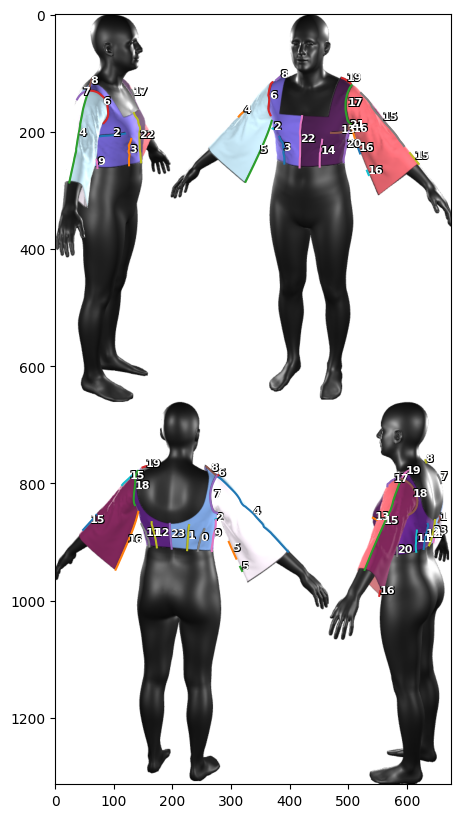

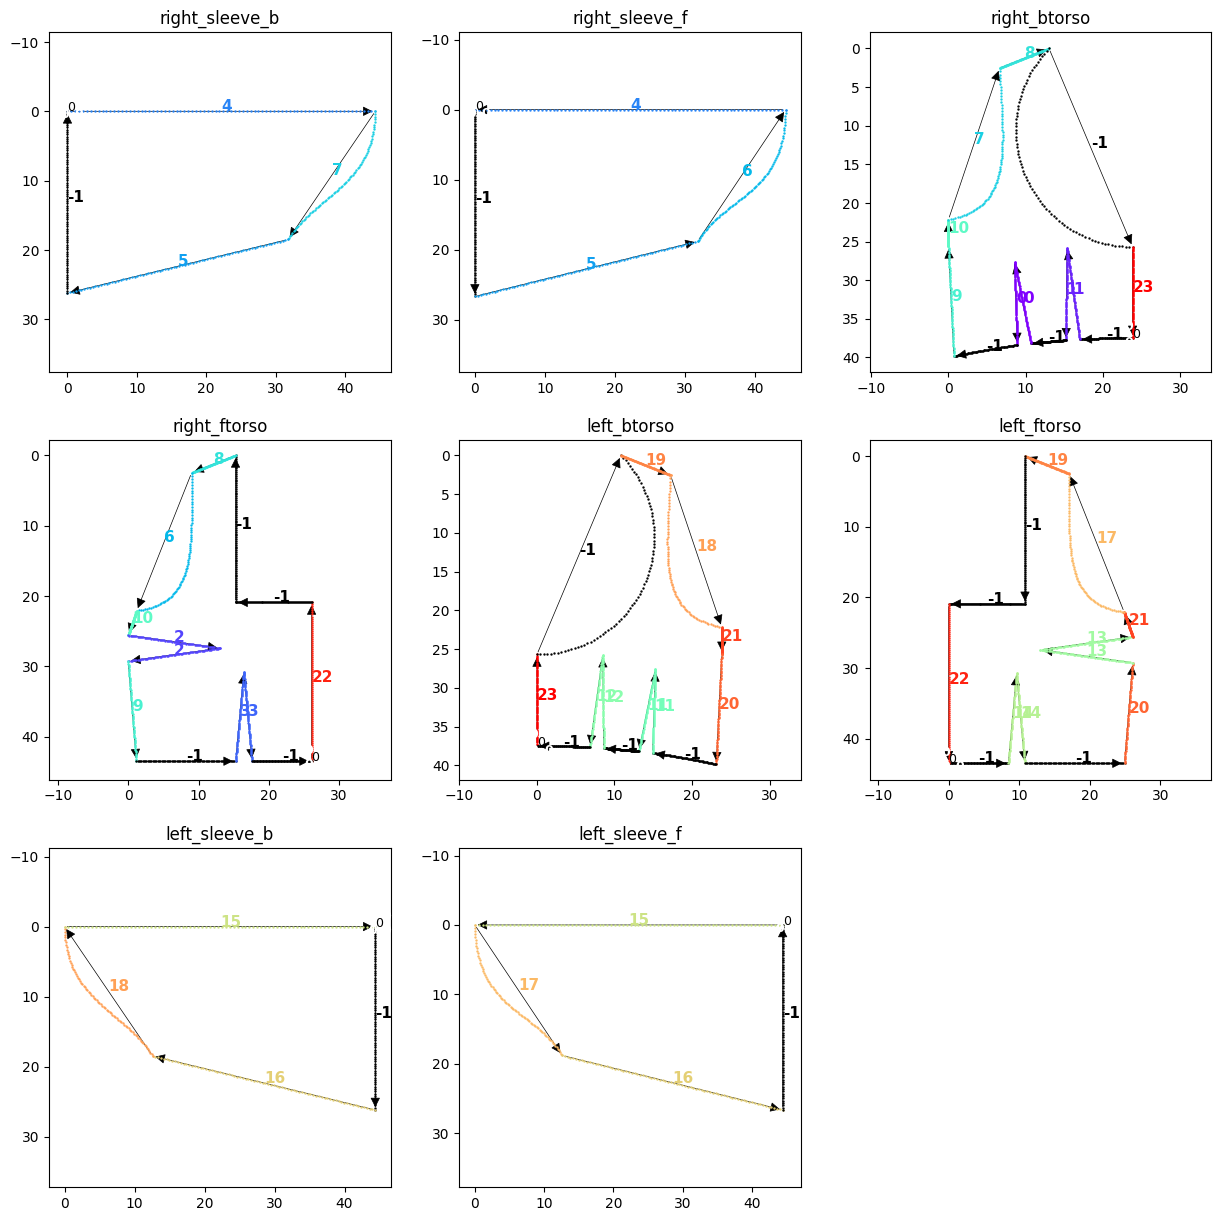

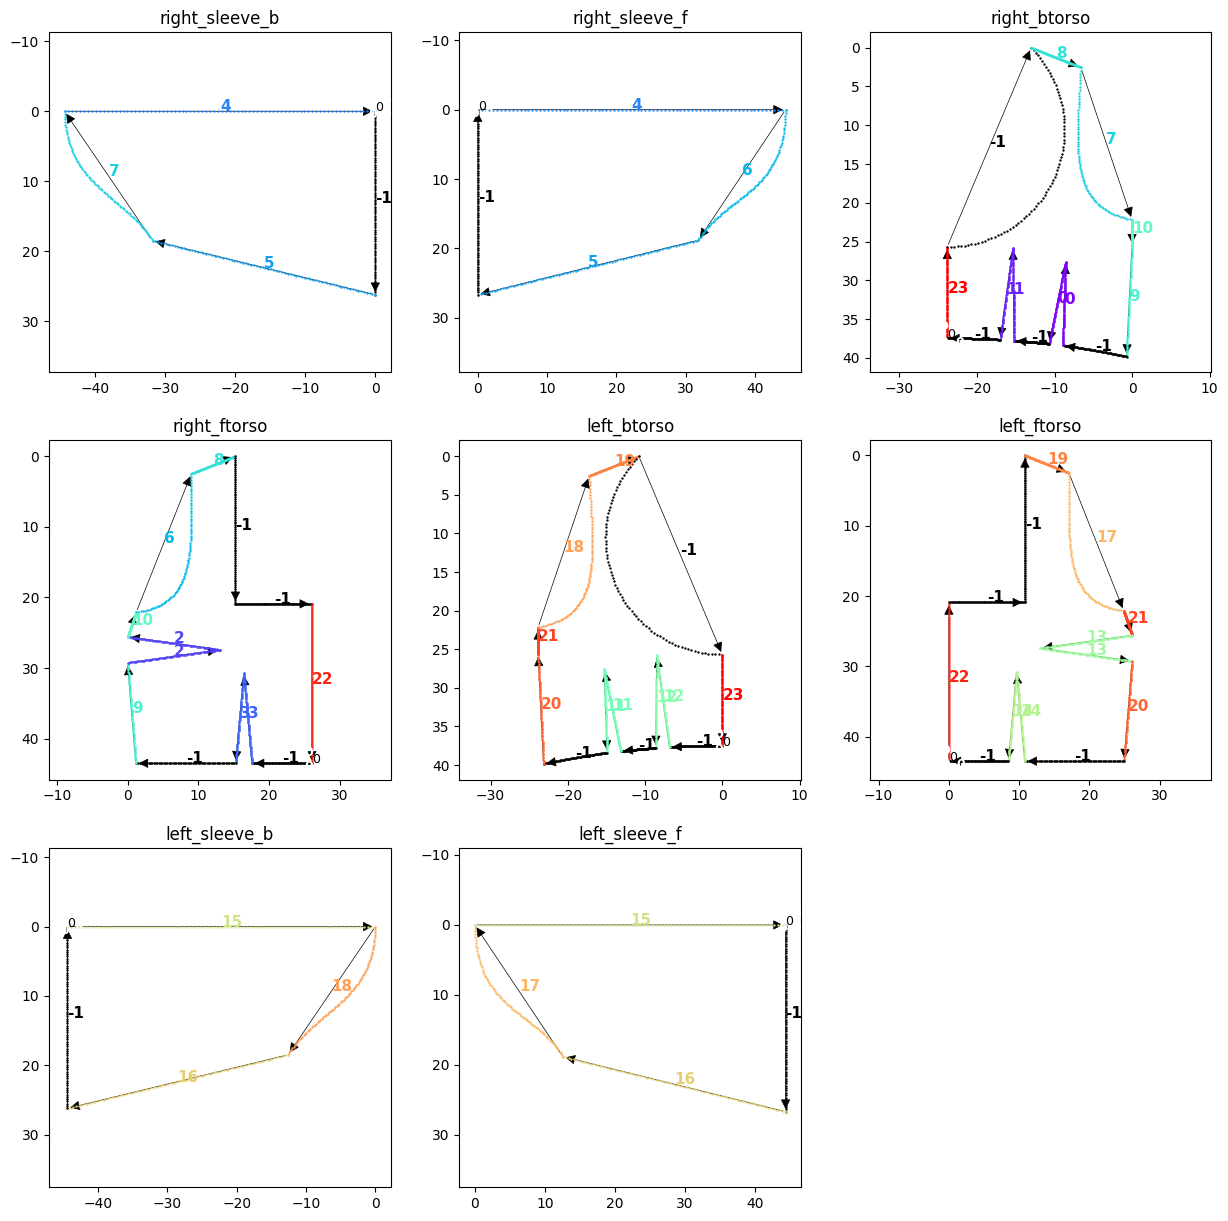

In [251]:
panel_name_refine_map = {
    'left_collar_back'      : " collar left back",
    'left_collar_front'     : " collar left front",
    'right_collar_back'     : " collar right back",
    'right_collar_front'    : " collar right front",
    'left_hood'             : " hood left",
    'right_hood'            : " hood right",
    'pant_b_l'              : " pant left back",
    'pant_b_r'              : " pant right back",
    'pant_f_l'              : " pant left front",
    'pant_f_r'              : " pant right front",
    'pant_l_cuff_b'         : " pant cuff left back",
    'pant_l_cuff_f'         : " pant cuff left front",
    'pant_l_cuff_skirt_b'   : " pant cuff skirt left back",
    'pant_l_cuff_skirt_f'   : " pant cuff skirt left front",
    'pant_r_cuff_b'         : " pant cuff right back",
    'pant_r_cuff_f'         : " pant cuff right front",
    'pant_r_cuff_skirt_b'   : " pant cuff skirt right back",
    'pant_r_cuff_skirt_f'   : " pant cuff skirt right front",
    'left_btorso'           : " torso left back",
    'left_ftorso'           : " torso left front",
    'right_btorso'          : " torso right back",
    'right_ftorso'          : " torso right front",
    'left_sleeve_b'         : " sleeve left back",
    'left_sleeve_f'         : " sleeve left front",
    'skirt_back'            : " skirt back",
    'skirt_front'           : " skirt front",
    'right_sleeve_b'        : " sleeve right back",
    'right_sleeve_f'        : " sleeve right front",
    'sl_left_cuff_b'        : " sleeve cuff left back",
    'sl_left_cuff_f'        : " sleeve cuff left front",
    'sl_left_cuff_skirt_b'  : " sleeve cuff skirt left back",
    'sl_left_cuff_skirt_f'  : " sleeve cuff skirt left front",
    'sl_right_cuff_b'       : " sleeve cuff right back",
    'sl_right_cuff_f'       : " sleeve cuff right front",
    'sl_right_cuff_skirt_b' : " sleeve cuff skirt right back",
    'sl_right_cuff_skirt_f' : " sleeve cuff skirt right front",
    'wb_back'               : " waist band back",
    'wb_front'              : " waist band front",
}

side_list = get_poc_dataset_view_name_list()

IDX = random.randint(0, len(garment_code_data_df) - 1)
print(IDX)
garment_path = garment_code_data_df["garment_path"].tolist()[IDX]
print(garment_path)

view_label_dict, sewing_pattern = read_poc_datapoint(
    garment_path, side_list, panel_name_refine_map
)

n_side    = random.randint(2, 4) 
sampled_side_list = random.sample(side_list, n_side)

combined_label = combine_images_and_labels(
    list(map(lambda x: view_label_dict[x], sampled_side_list)),
    sewing_pattern,
)

plt.figure(figsize=(10, 10))
plt.imshow(combined_label.img)
for seam_line_dict in combined_label.seam_line_dict_list :
    for seam_line_idx, seam_line in seam_line_dict.items() :
        for segment_idx, segment in enumerate(seam_line.segment_vert_pos_arr_list) :
            plt.plot(segment[:, 0],segment[:, 1])
            text_obj = plt.annotate(
                f"{seam_line_idx}",
                (segment[:, 0].mean(), segment[:, 1].mean()),
                fontsize=8, color="white", fontweight="bold"
            )
            for dx, dy in [(-1, -1), (-1, 1), (1, -1), (1, 1)]:
                plt.annotate(
                    f"{seam_line_idx}",
                    (segment[:, 0].mean() + dx, segment[:, 1].mean() + dy),
                    fontsize=8, fontweight="bold",
                    zorder=text_obj.zorder - 1
                )
plt.show()

combined_label.sewing_pattern.draw()
plt.show()

combined_label.mirror_back_panel_horizontally()
combined_label.unifiy_loop_direction()
combined_label.sewing_pattern.draw()

41693
garments_5000_12/default_body/rand_ECKZYVS8G1


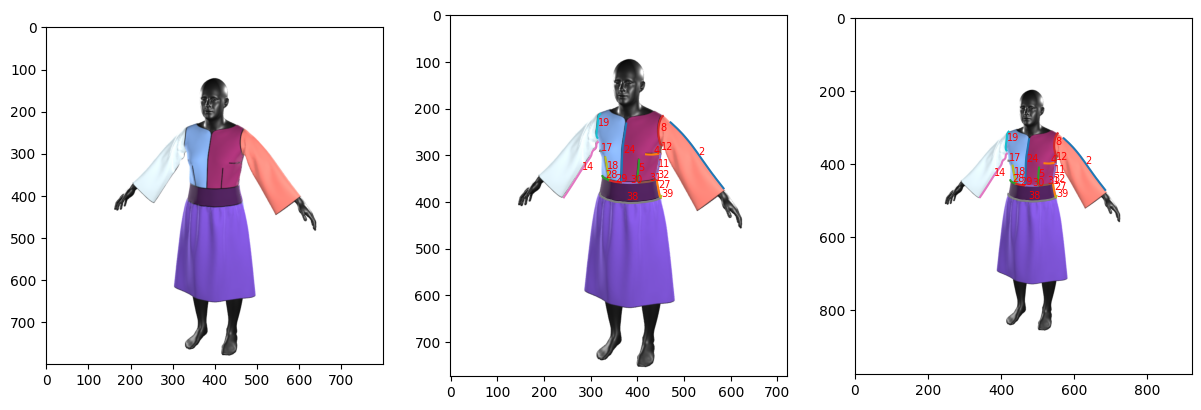

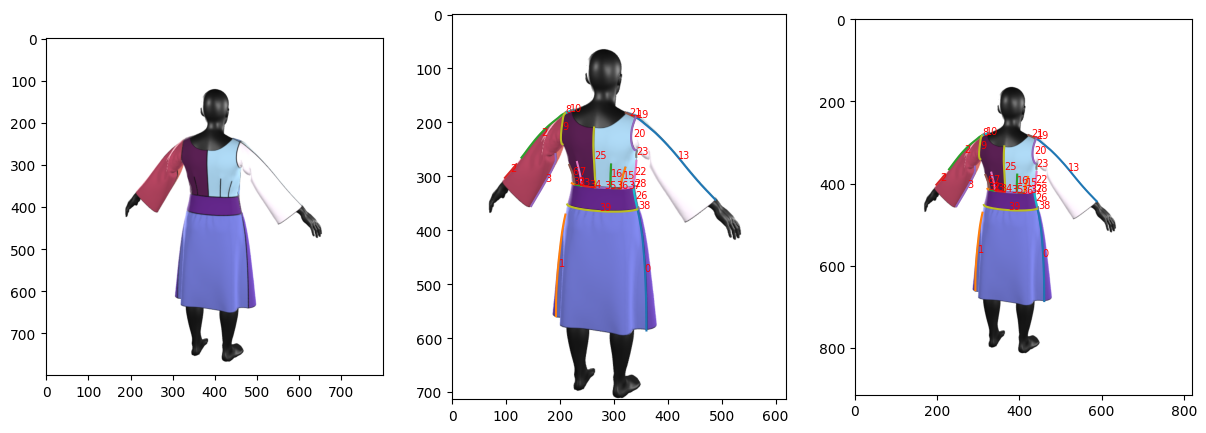

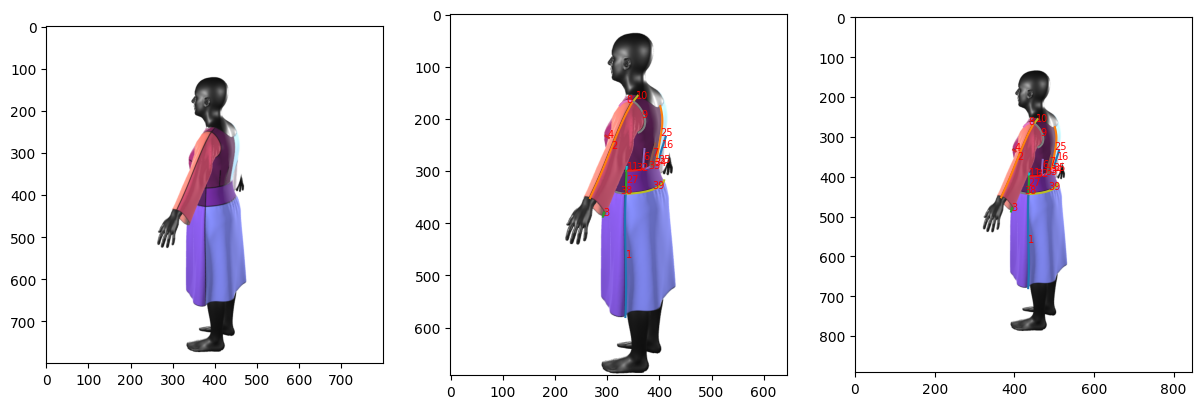

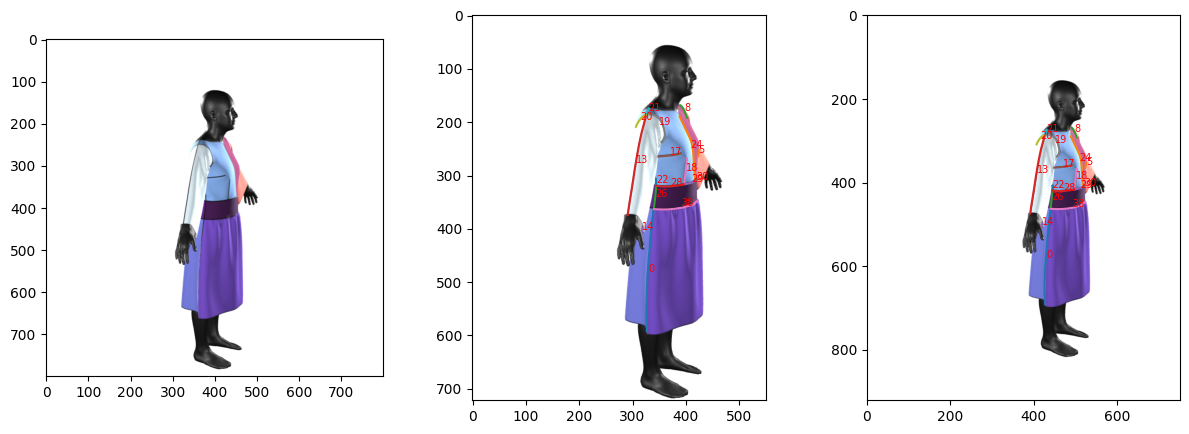

In [6]:
side_list = ["front", "back", "left", "right"]

IDX = random.randint(0, len(garment_code_data_df) - 1)
print(IDX)
garment_path = garment_code_data_df["garment_path"].tolist()[IDX]
print(garment_path)

view_label_dict, sewing_pattern = read_poc_datapoint(
    garment_path,
)

n_side    = random.randint(1, 4) 
sampled_side_list = random.sample(side_list, n_side)

view_label_list = []
for side in sampled_side_list :
    view_label_list.append(view_label_dict[side])




NROWS = 1
NCOLS = 4
FIGLEN = 5
for side in ["front", "back", "left", "right"] :
    plt.figure(figsize=(FIGLEN * NCOLS, FIGLEN * NROWS))
    fig_idx = 1


    ax = plt.subplot(NROWS, NCOLS, fig_idx); fig_idx += 1
    ax.imshow(view_label_dict[side].img)

    single_view_data = view_label_dict[side]

    IMG_H, IMG_W = single_view_data.img.size
    img_bbox_x1, img_bbox_y1, img_bbox_x2, img_bbox_y2 = get_bbox_from_mask(single_view_data.img_foreground_mask)
    crop_t = random.randint(0, img_bbox_y1)
    crop_b = random.randint(img_bbox_y2, IMG_H - 1)
    crop_l = random.randint(0, img_bbox_x1)
    crop_r = random.randint(img_bbox_x2, IMG_W - 1)
    
    single_view_data.crop(crop_l, crop_t, crop_r, crop_b)




    ax = plt.subplot(NROWS, NCOLS, fig_idx); fig_idx += 1
    ax.imshow(single_view_data.img)
    for seam_line_idx, seam_line in single_view_data.seam_line_dict.items() :
        
        for segment_idx, segment in enumerate(seam_line.segment_vert_pos_arr_list) :
            ax.plot(
                segment[:, 0],
                segment[:, 1],
            )
            ax.annotate(
                f"{seam_line_idx}",
                (
                    segment[:, 0].mean(),
                    segment[:, 1].mean(),
                ),
                c="red", fontsize=7
            )
    
    single_view_data.pad(100, 100, 100, 100)

    ax = plt.subplot(NROWS, NCOLS, fig_idx); fig_idx += 1
    ax.imshow(single_view_data.img)

    for seam_line_idx, seam_line in single_view_data.seam_line_dict.items() :
        for segment_idx, segment in enumerate(seam_line.segment_vert_pos_arr_list) :
            ax.plot(
                segment[:, 0],
                segment[:, 1],
            )
            ax.annotate(
                f"{seam_line_idx}",
                (
                    segment[:, 0].mean(),
                    segment[:, 1].mean(),
                ),
                c="red", fontsize=7
            )
    
    plt.show()

In [70]:
# IDX = random.randint(0, len(garment_code_data_df) - 1)
# print(IDX)
# garment_path = garment_code_data_df["garment_path"].tolist()[IDX]
# print(garment_path)
# (
#     rendered_image_dict,
#     panel_svg_path_dict,
#     stitch_dict,
#     panel_vertex_mask_dict,
#     vertex_visibility_mask_dict,
#     projected_vertex_pose_dict,
#     fltrd_vis_seam_line_dict,
# ) = read_poc_datapoint(
#     os.path.join(DATASET_ROOT, garment_path),
#     return_data_list = [
#         "rendered_image_dict",
#         "panel_svg_path_dict",
#         "stitch_dict",
#         "panel_vertex_mask_dict",
#         "vertex_visibility_mask_dict",
#         "projected_vertex_pose_dict",
#         "fltrd_vis_seam_line_dict",
#     ]
# )
# sewing_pattern = SewingPattern(
#     panel_svg_path_dict,
#     stitch_dict,
# )
# SIDE = "front"
# seam_line_dict = {}
# for seam_line_idx, seam_line in fltrd_vis_seam_line_dict[SIDE].items() :
#     seam_line_dict[seam_line_idx] = ParameterizedSeamLine(
#         whole_stch_vert_idx_arr = seam_line["raw_idx_arr"],
#         whole_stch_vert_vis_mask = seam_line["raw_vis_mask"],
#         segment_vert_idx_arr_list = seam_line["segment_idx_arr_list"],
#         segment_vert_pos_arr_list = seam_line["segment_pos_arr_list"],
#         segment_edge_len_arr_list = seam_line["segment_edge_len_arr_list"],
#         segment_t_arr_list = seam_line["segment_t_arr_list"],
#         segment_u_arr_list = seam_line["segment_u_arr_list"],
#         segment_v_arr_list = seam_line["segment_v_arr_list"],
#     )
# single_view_label_dict = {}
# for side in ["front", "back", "left", "right"] :
#     single_view_label_dict[side] = SingleViewLabel(
#         rendered_image_dict[side],
#         img_foreground_mask = np.array(rendered_image_dict[SIDE].getchannel("A")),
#         vertex_visibility_mask_dict[side],
#         projected_vertex_pose_dict[side],
#         fltrd_vis_seam_line_dict[side],
#     )
# NROWS = 1
# NCOLS = 2
# FIGLEN = 5
# for side in ["front", "back", "left", "right"] :
#     fig_idx = 1

#     single_view_data = single_view_label_dict[side]

#     plt.figure(figsize=(FIGLEN * NCOLS, FIGLEN * NROWS))

#     ax = plt.subplot(NROWS, NCOLS, fig_idx); fig_idx += 1
#     ax.imshow(single_view_data.img_arr)

#     ax = plt.subplot(NROWS, NCOLS, fig_idx); fig_idx += 1
#     ax.imshow(single_view_data.img_arr)
#     for seam_line_idx, seam_line in single_view_data.seam_line_dict.items() :
        
#         for segment_idx, segment in enumerate(seam_line.segment_vert_pos_arr_list) :
#             ax.plot(
#                 segment[:, 0],
#                 segment[:, 1],
#             )
#             ax.annotate(
#                 f"{seam_line_idx}",
#                 (
#                     segment[:, 0].mean(),
#                     segment[:, 1].mean(),
#                 ),
#                 c="red"
#             )
            
#     plt.show()

39603
garments_5000_12/default_body/rand_E9KIFH0AZG


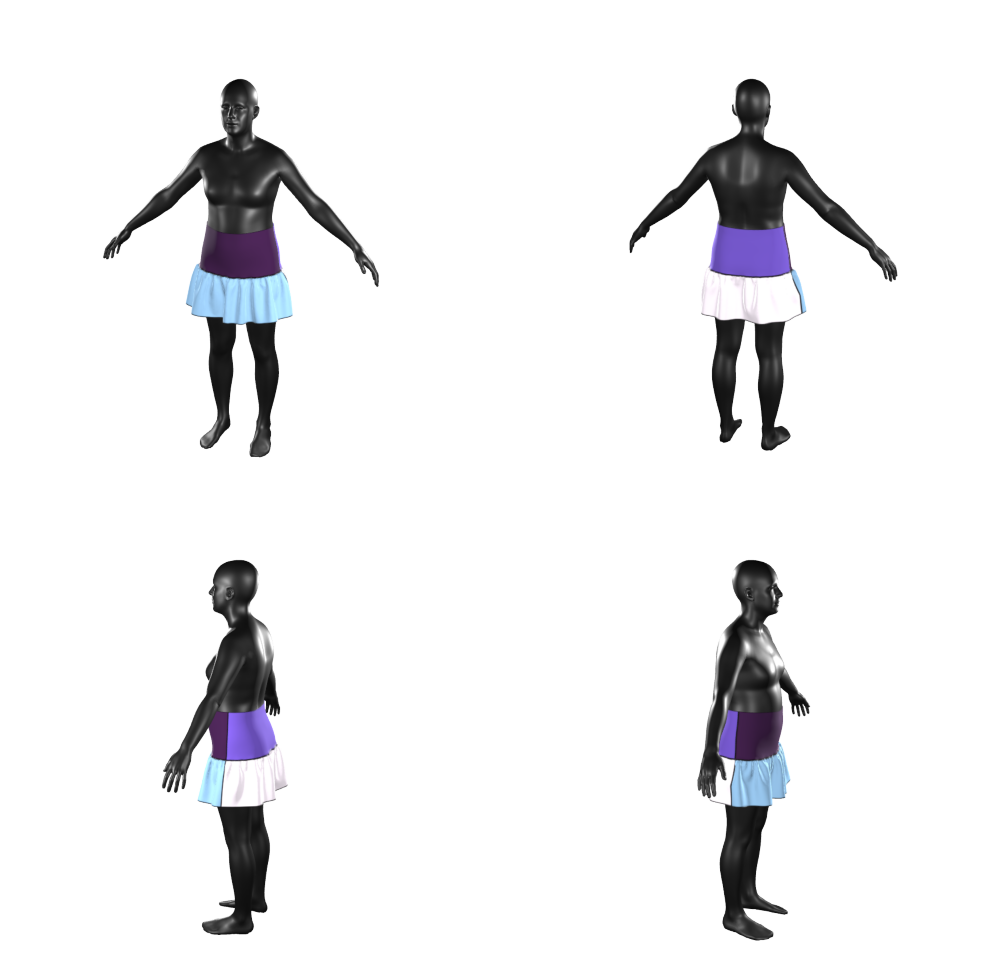

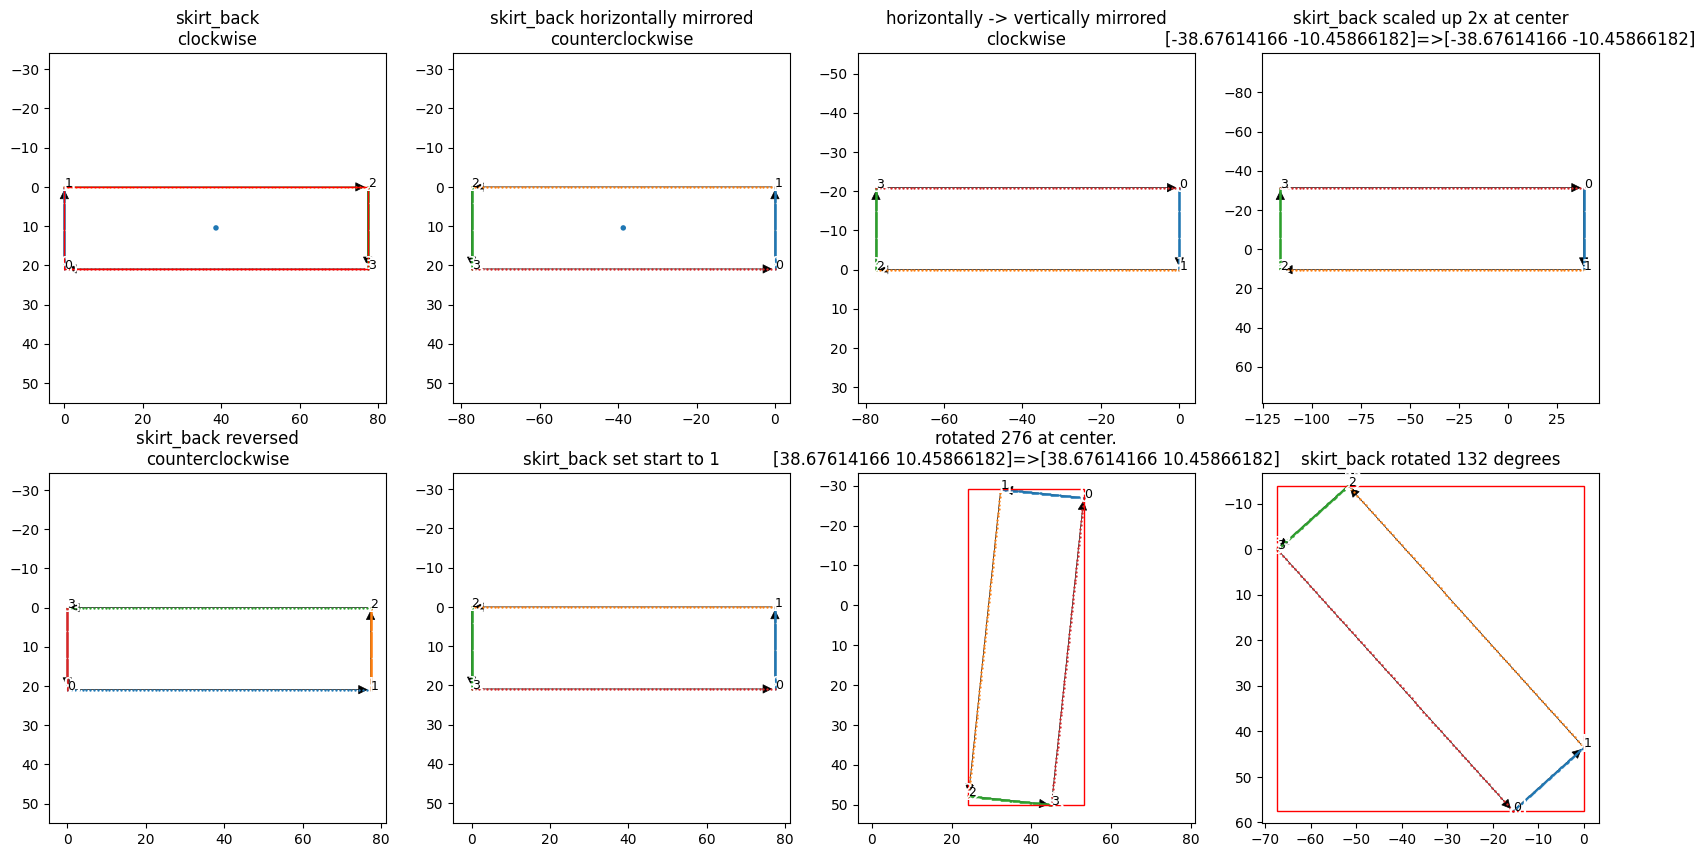

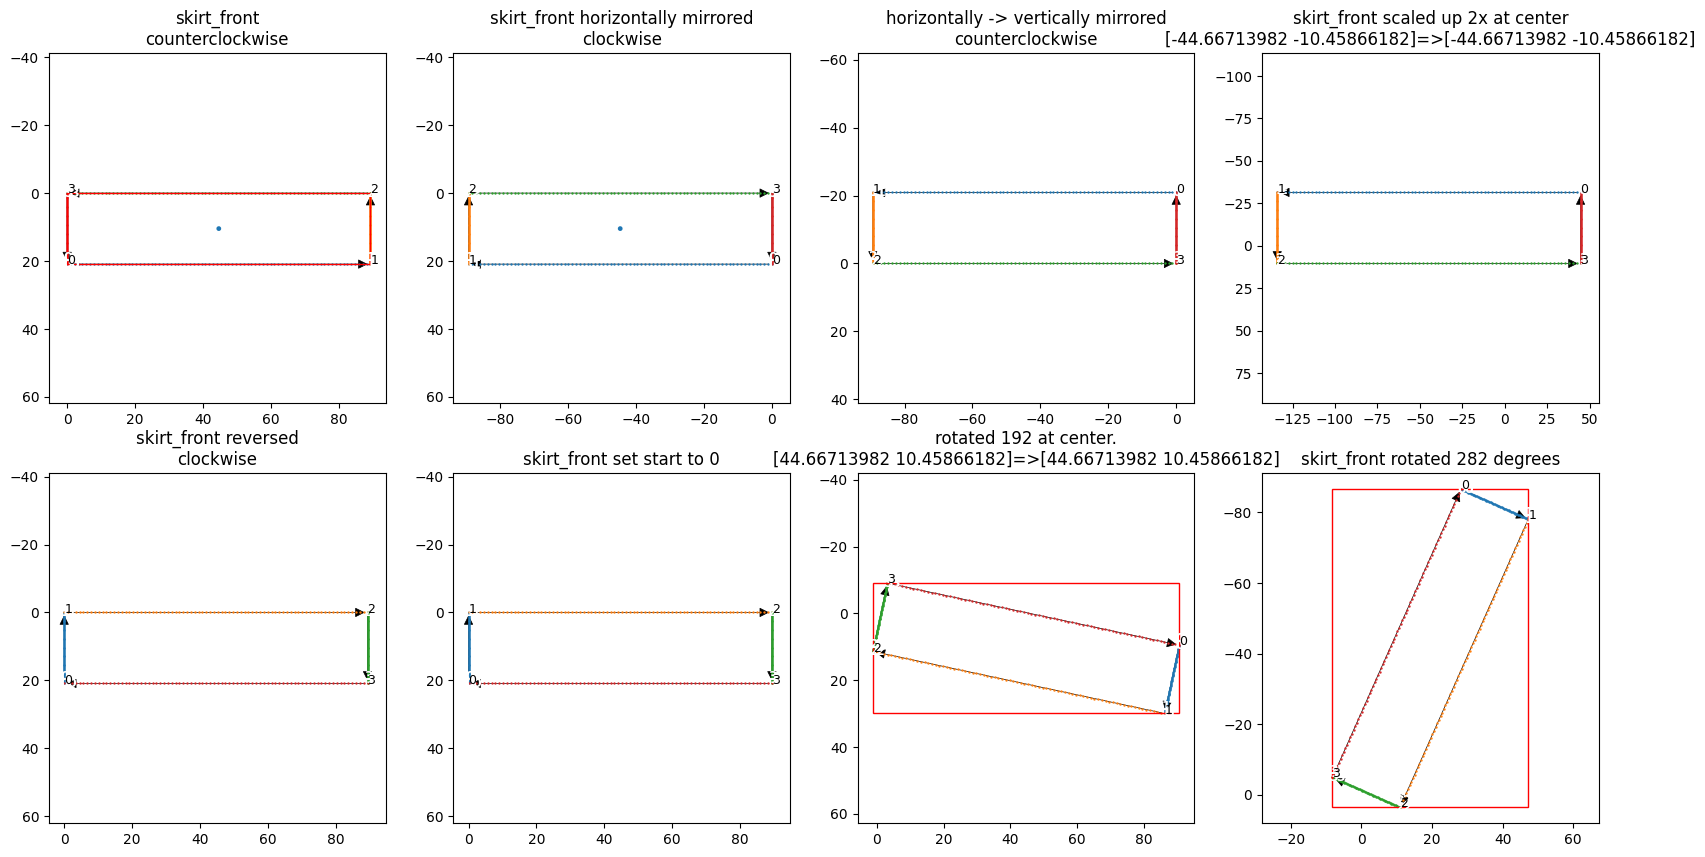

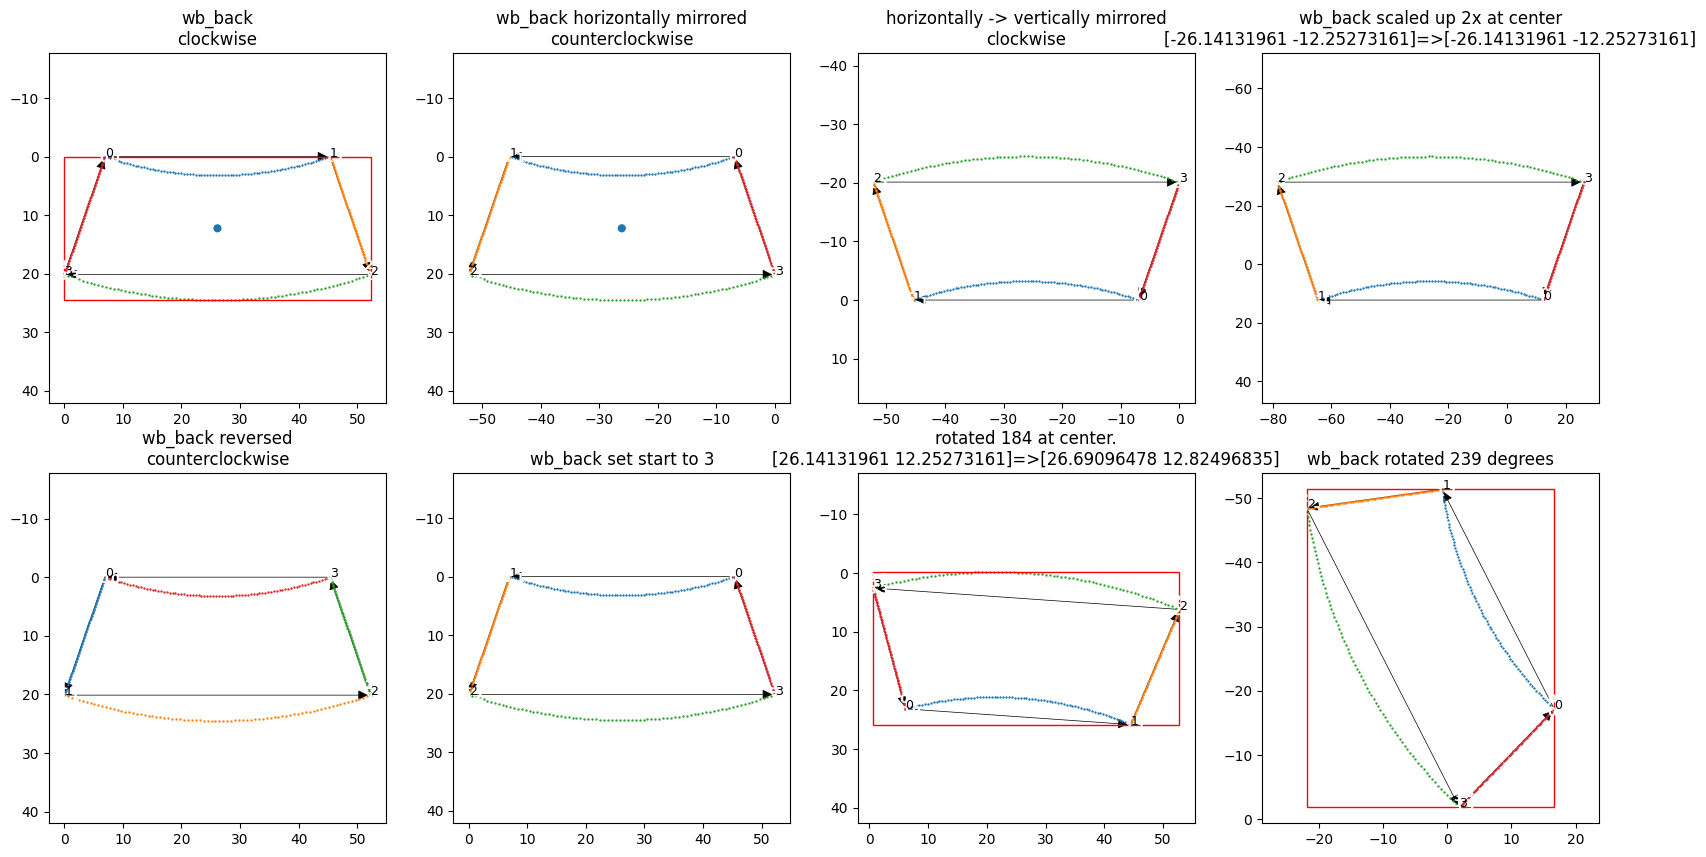

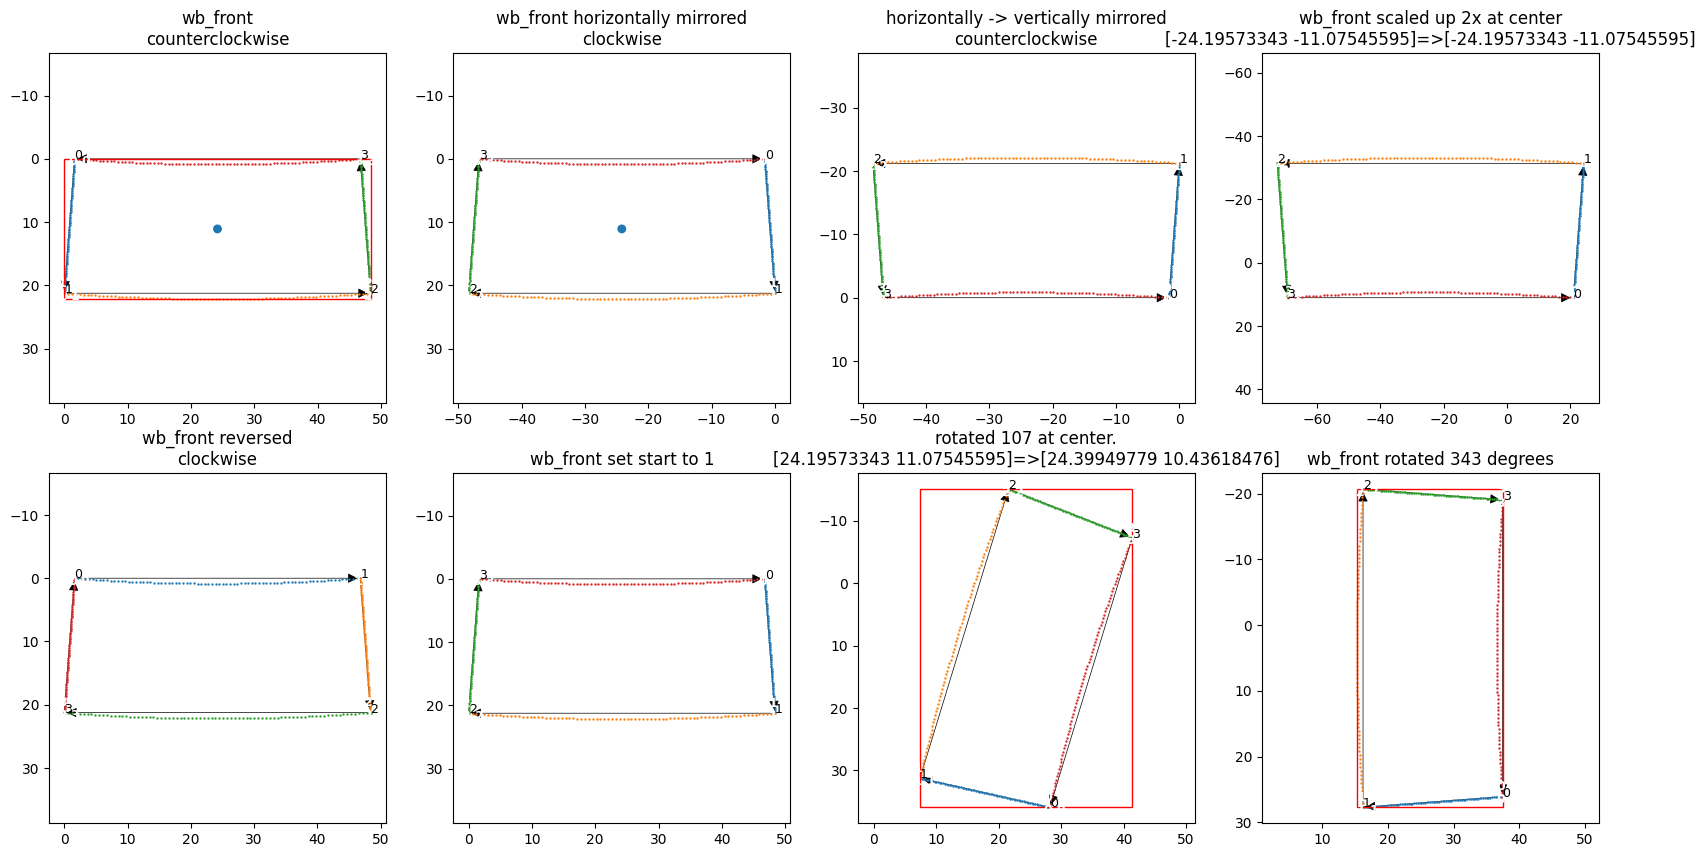

In [4]:
IDX = random.randint(0, len(garment_code_data_df) - 1)
print(IDX)

garment_path = garment_code_data_df["garment_path"].tolist()[IDX]
print(garment_path)


(
    rendered_image_dict,
    panel_svg_path_dict,
    stitch_dict,
    panel_vertex_mask_dict,
    vertex_visibility_mask_dict,
    projected_vertex_pose_dict,
    fltrd_vis_seam_line_dict,
) = read_poc_datapoint(
    os.path.join(DATASET_ROOT, garment_path),
    return_data_list = [
        "rendered_image_dict",
        "panel_svg_path_dict",
        "stitch_dict",
        "panel_vertex_mask_dict",
        "vertex_visibility_mask_dict",
        "projected_vertex_pose_dict",
        "fltrd_vis_seam_line_dict",
    ]
)

NROWS = 2
NCOLS = 2 # /len(rendered_image_dict)

FIGLEN = 5

plt.figure(figsize=(FIGLEN * NCOLS, FIGLEN * NROWS))
for side_idx, (side, image) in enumerate(rendered_image_dict.items()) :
    ax = plt.subplot(NROWS, NCOLS, side_idx + 1)
    plt.imshow(image)
    plt.tight_layout()
    plt.axis("off")
plt.show()



NROWS = 2
NCOLS = 4
FIGLEN = 5
for panel_idx, (panel_name, panel_svg_path) in enumerate(panel_svg_path_dict.items()) :
    fig_idx = 1
    panel = SVGPanel(panel_svg_path_dict[panel_name][0])

    panel_copied = deepcopy(panel)

    plt.figure(figsize=(FIGLEN * NCOLS, FIGLEN * NROWS))


    panel.draw(
        ax = plt.subplot(NROWS, NCOLS, fig_idx),
        panel_name = "{}\n{}".format(
            panel_name,
            "clockwise" if panel.is_clockwise() else "counterclockwise"
        ),
    ); fig_idx += 1
    # Draw bbox
    xmin, ymin, xmax, ymax = panel.bbox()
    plt.gca().add_patch(patches.Rectangle(
        (xmin, ymin), xmax - xmin, ymax - ymin,
        fill=False,
        edgecolor='red',
        linewidth=1
    )) 
    # Draw center
    plt.gca().add_patch(patches.Circle(
        xy = panel.get_center(),
        radius=0.7,
        fill=True,
    ))
    

    panel.mirror_horizontal()
    panel.draw(
        ax = plt.subplot(NROWS, NCOLS, fig_idx),
        panel_name = "{}\n{}".format(
            f"{panel_name} horizontally mirrored",
            "clockwise" if panel.is_clockwise() else "counterclockwise"
        ),
    ); fig_idx += 1
    plt.gca().add_patch(patches.Circle(
        xy = panel.get_center(),
        radius=0.7,
        fill=True,
    ))

    panel.mirror_vertical()
    panel.draw(
        ax = plt.subplot(NROWS, NCOLS, fig_idx),
        panel_name = "{}\n{}".format(
            f"horizontally -> vertically mirrored",
            "clockwise" if panel.is_clockwise() else "counterclockwise"
        ),
    ); fig_idx += 1

    
    SCALE_FACTOR = 2
    center_before = panel.get_center()
    panel.scale(SCALE_FACTOR, pivot=center_before)
    center_after = panel.get_center()
    panel.draw(
        ax = plt.subplot(NROWS, NCOLS, fig_idx),
        panel_name = "{}\n{}".format(
            f"{panel_name} scaled up {SCALE_FACTOR}x at center",
            f"{center_before}=>{center_after}"
        ),
    ); fig_idx += 1

    # ROW 2
    panel_copied.reverse_path()
    panel_copied.draw(
        ax = plt.subplot(NROWS, NCOLS, fig_idx),
        panel_name = "{}\n{}".format(
            f"{panel_name} reversed",
            "clockwise" if panel_copied.is_clockwise() else "counterclockwise"
        ),
    ); fig_idx += 1
    
    

    new_start_idx = random.randint(0, len(panel_copied.svg_path) - 1)
    panel_copied.set_start(new_start_idx)
    panel_copied.draw(
        ax = plt.subplot(NROWS, NCOLS, fig_idx),
        panel_name = f"{panel_name} set start to {new_start_idx}"
    ); fig_idx += 1
    
    
    angle = random.randint(0, 360)
    center_before = panel_copied.get_center()
    panel_copied.rotate_clockwise(angle, pivot=center_before)
    center_after = panel_copied.get_center()
    panel_copied.draw(
        ax = plt.subplot(NROWS, NCOLS, fig_idx),
        panel_name = f"rotated {angle} at center.\n{center_before}=>{center_after}"
    ); fig_idx += 1
    xmin, ymin, xmax, ymax = panel_copied.bbox()
    plt.gca().add_patch(patches.Rectangle(
        (xmin, ymin), xmax - xmin, ymax - ymin,
        fill=False,
        edgecolor='red',
        linewidth=1
    )) 
    
    angle = random.randint(0, 360)
    panel_copied.rotate_clockwise(angle)
    panel_copied.draw(
        ax = plt.subplot(NROWS, NCOLS, fig_idx),
        panel_name = f"{panel_name} rotated {angle} degrees"
    ); fig_idx += 1
    xmin, ymin, xmax, ymax = panel_copied.bbox()
    plt.gca().add_patch(patches.Rectangle(
        (xmin, ymin), xmax - xmin, ymax - ymin,
        fill=False,
        edgecolor='red',
        linewidth=1
    )) 
    
    
    plt.show()
    
    


In [13]:
for panel_name, panel_svg_path in panel_svg_path_dict.items() :
    print(type(panel_svg_path[0]))
    print(panel_svg_path[0].bbox())
    # print(panel_svg_path.bbox())

<class 'svgpathtools.path.Path'>
(0.0, 24.571935593760536, 0.0, 22.772683414538363)
<class 'svgpathtools.path.Path'>
(0.0, 21.23929701940479, 0.0, 5.3969700000000005)
<class 'svgpathtools.path.Path'>
(0.0, 24.57193559376054, -3.552713678800501e-15, 23.11986346887668)
<class 'svgpathtools.path.Path'>
(0.0, 21.23929701940479, 0.0, 5.3969700000000005)
<class 'svgpathtools.path.Path'>
(0.0, 34.704375337380995, 0.0, 19.45499731960336)
<class 'svgpathtools.path.Path'>
(0.0, 34.704375337380995, 0.0, 19.45499731960336)
<class 'svgpathtools.path.Path'>
(0.0, 34.794962500000004, 0.0, 42.88983)
<class 'svgpathtools.path.Path'>
(-2.220446049250313e-16, 30.408937499999993, 0.0, 40.54146)
<class 'svgpathtools.path.Path'>
(0.0, 23.83805, 0.0, 39.836598011934875)
<class 'svgpathtools.path.Path'>
(0.0, 26.082300000000004, 0.0, 43.505597770135154)
<class 'svgpathtools.path.Path'>
(0.0, 39.1358, 0.0, 4.69674)
<class 'svgpathtools.path.Path'>
(0.0, 45.19799999999999, 0.0, 4.69674)
<class 'svgpathtools.pat

In [ ]:
stitch_manager = StitchDict(stitch_dict)

copied_stitch_manager = deepcopy(stitch_manager)

In [91]:
copied_stitch_manager

{0: Stitch(panel_0='right_ftorso', edge_0=6, panel_1='right_ftorso', edge_1=5, stitch_direction=False), 1: Stitch(panel_0='right_ftorso', edge_0=10, panel_1='right_ftorso', edge_1=9, stitch_direction=False), 2: Stitch(panel_0='right_btorso', edge_0=4, panel_1='right_btorso', edge_1=5, stitch_direction=False), 3: Stitch(panel_0='right_btorso', edge_0=1, panel_1='right_btorso', edge_1=2, stitch_direction=False), 4: Stitch(panel_0='right_collar_front', edge_0=3, panel_1='right_collar_back', edge_1=0, stitch_direction=False), 5: Stitch(panel_0='right_ftorso', edge_0=1, panel_1='right_collar_front', edge_1=0, stitch_direction=False), 6: Stitch(panel_0='right_btorso', edge_0=11, panel_1='right_collar_back', edge_1=3, stitch_direction=False), 7: Stitch(panel_0='right_ftorso', edge_0=2, panel_1='right_btorso', edge_1=10, stitch_direction=False), 8: Stitch(panel_0='right_ftorso', edge_0=7, panel_1='right_btorso', edge_1=7, stitch_direction=False), 9: Stitch(panel_0='right_ftorso', edge_0=4, pan

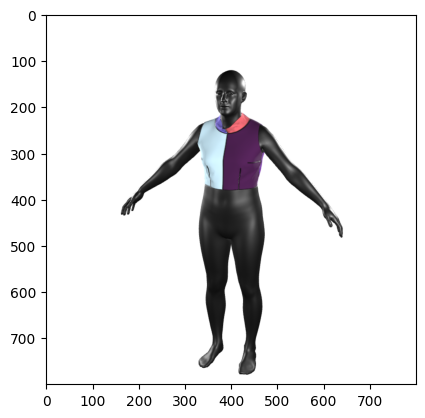

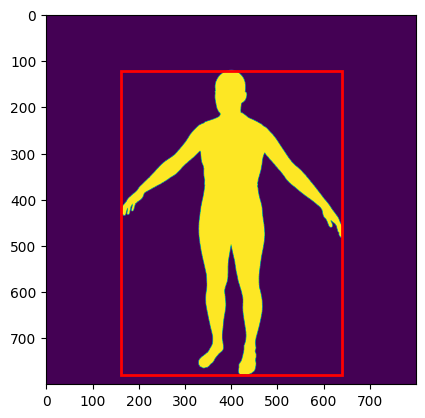

In [71]:
SIDE = "front"
img_arr = np.array(rendered_image_dict[SIDE].convert('RGB'))
img_foreground_mask = np.array(rendered_image_dict[SIDE].getchannel("A"))

(x1, y1, x2, y2) = get_bbox_from_mask(img_foreground_mask)

plt.imshow(img_arr)
plt.show()

fig, ax = plt.subplots()
ax.imshow(img_foreground_mask)
ax.add_patch(patches.Rectangle(
    (x1, y1), x2 - x1, y2 - y1,
    fill=False,
    edgecolor='red',
    linewidth=2
))
plt.show()
